In [32]:
import json
from GameGenerator import HexState
import numpy as np
from typing import List

def load_game_state(file_path: str) -> dict:
    """
    Load game state JSON from a file.
    :param file_path: Path to the JSON file.
    :return: Parsed game state as a dictionary.
    """
    with open(file_path, 'r') as file:
        return json.load(file)

def create_hex_state_from_json(json_data: dict) -> "HexState":
    """
    Create a HexState instance from JSON data.
    :param json_data: Parsed JSON data.
    :return: HexState instance.
    """
    # Extract the board and player data
    board_data = json_data["board"]
    player = json_data["player"]
    
    # Convert the board into a numpy array
    board_array = np.array([[hex["R"], hex["S"], hex["Q"], hex["Index"], hex["Owner"]] for hex in board_data])
    
    # Create and return the HexState instance
    return HexState(board=board_array, player=player)




In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_hex_board_final(board: np.ndarray):
    """
    Visualize the hexagonal board with correct orientation, flipped vertically, 
    and each hexagon rotated by 90 degrees.
    
    Parameters:
    - board: numpy array with each row containing [R, S, Q, Index, Owner].
    - radius: radius of the hexagon grid.
    """
    radius = 11
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Define colors for each owner
    owner_colors = {
        0: 'lightgray',  # No owner (default empty hex)
        1: 'red',        # Red player
        2: 'green',      # Green player
        3: 'blue',       # Blue player
    }

    # Function to calculate hexagon corners with 90-degree rotation
    def hex_corners(center_x, center_y, size=1):
        return [
            (
                center_x + size * np.cos(np.radians(90) + np.radians(60) * i),
                center_y + size * np.sin(np.radians(90) + np.radians(60) * i)
            )
            for i in range(6)
        ]

    # Plot each hex cell
    for cell in board:
        r, s, q, index, owner = cell
        
        # Hexagonal grid layout with rotation and flip
        x = np.sqrt(3) * (q + r / 2)  # Adjusted x for rotated grid
        y = -3/2 * r                  # Adjusted y for rotated and flipped grid

        # Create a hexagonal patch
        hex_color = owner_colors.get(owner, 'black')
        hex_patch = patches.Polygon(hex_corners(x, y, size=0.95), closed=True,
                                     edgecolor='black', facecolor=hex_color)
        ax.add_patch(hex_patch)

        # Add the index text in the center of the hex
        ax.text(x, y, str(index), ha='center', va='center', fontsize=8, color='black')

    # Set aspect ratio and axis limits
    ax.set_aspect('equal')
    ax.axis('off')

    # Adjust the viewing window to center the hexagonal grid
    ax.set_xlim(-radius * 2, radius * 2)
    ax.set_ylim(-radius * np.sqrt(3), radius * np.sqrt(3))
    
    plt.show()


In [34]:
import json
import random

def load_game_state(file_path):
    """Load game state from a JSON file."""
    with open(file_path, 'r') as file:
        return json.load(file)



In [35]:
# Example usage:
file_path = 'V:/MFF/bakalarka/gamestate.json'  # Path to your JSON file
game_state_json = load_game_state(file_path)

# Create the HexState
hex_state = create_hex_state_from_json(game_state_json)

# Print the state for verification
print(hex_state.board)
print(f"Current player: {hex_state.player}")

[[-11  11   0   0   0]
 [-11  10   1   1   2]
 [-11   9   2   2   2]
 ...
 [ 11  -9  -2 394   2]
 [ 11 -10  -1 395   2]
 [ 11 -11   0 396   0]]
Current player: 1


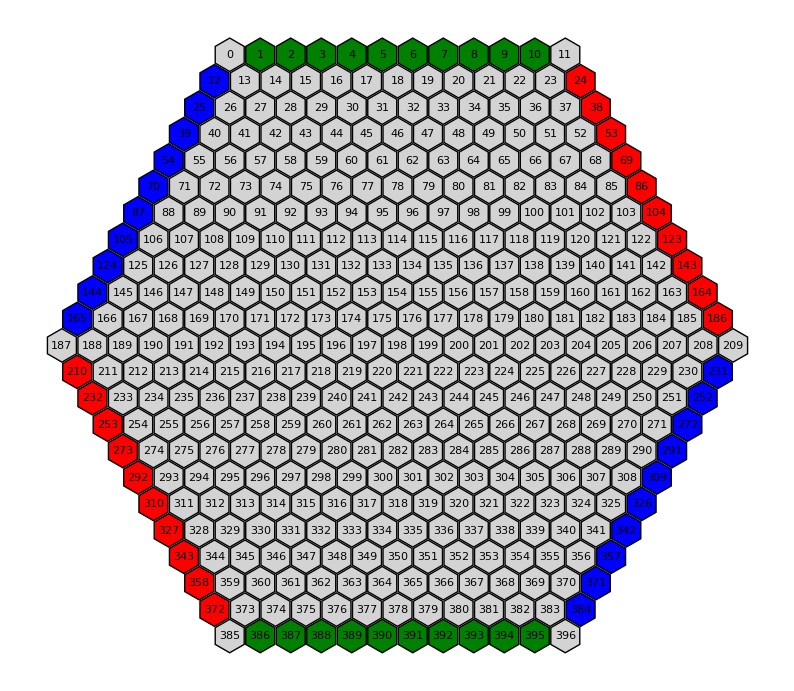

In [36]:
plot_hex_board_final(hex_state.board)

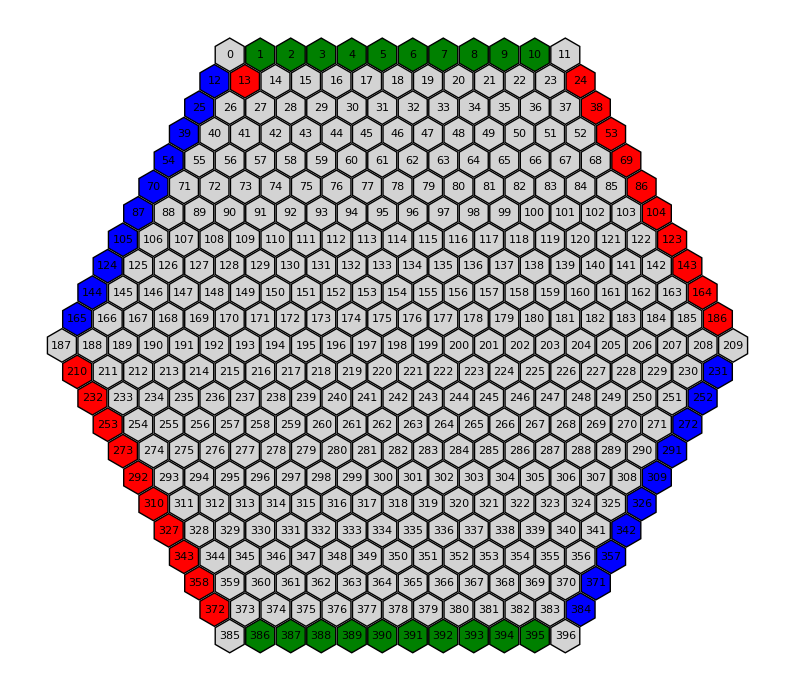

In [37]:
newState = hex_state.apply_move(13)

plot_hex_board_final(newState.board)

324


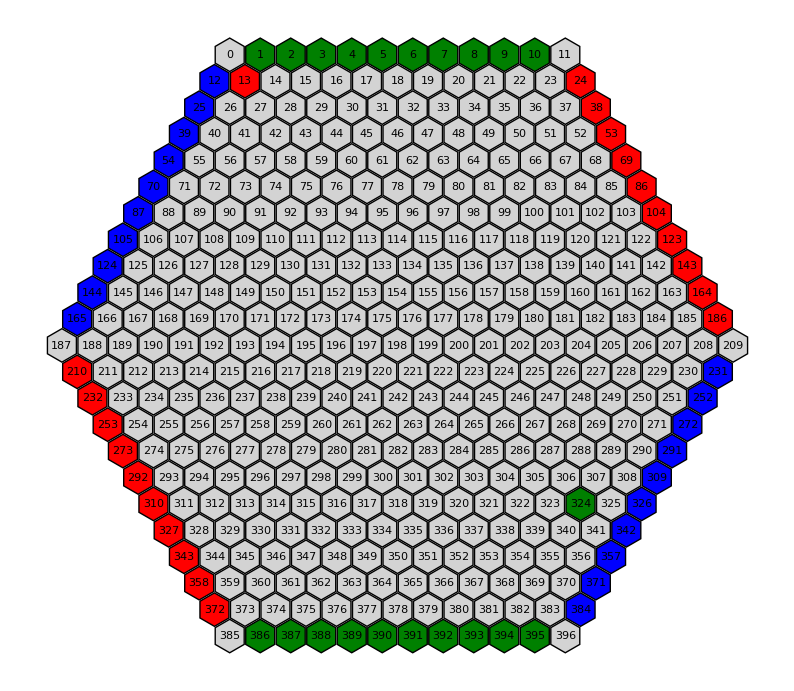

0

In [38]:
from montecarlo.node import Node
from montecarlo.montecarlo import MonteCarlo
import numpy as np
import random


# Function to find and add child nodes
def child_finder(node, _):
    """
    Generate child nodes for the current node.
    """
    state = node.state
    legal_moves = state.get_legal_moves()  # Get all legal moves
    for move in legal_moves:
        child_state = state.apply_move(move)  # Apply the move to create a new state
        child_node = Node(child_state)
        child_node.player_number = child_state.player  # Set the player for this node
        node.add_child(child_node)  # Add the new node as a child


# Function to evaluate a node during the simulation
def node_evaluator(node, _):
    """
    Evaluate the node for Monte Carlo simulations.
    """
    state = node.state
    if state.is_terminal():  # Run BFS only if the game is in a terminal state
        winner = state.get_winner()
        if winner == state.player:
            return 1
        elif winner is not None:
            return -1
        return 0
    else:
        # Use a heuristic evaluation for non-terminal states
        return 0


# Heuristic evaluation for intermediate states
def heuristic_evaluation(state):
    """
    Heuristically evaluate the board for the current player.
    Returns a score indicating how favorable the state is for the current player.
    """
    player_moves = len(state.get_legal_moves())
    opponent1 = (state.player % 3) + 1
    opponent2 = (opponent1 % 3) + 1
    opponent1_moves = len(state.get_legal_moves())
    opponent2_moves = len(state.get_legal_moves())

    # Example heuristic: Favor more moves for the current player
    return player_moves - (opponent1_moves + opponent2_moves) / 2


# Function to initialize the Monte Carlo tree
def initialize_montecarlo(hex_state: HexState):
    """
    Initialize the Monte Carlo tree for the HexState.
    """
    root_node = Node(hex_state)  # Create the root node for the current game state
    root_node.player_number = hex_state.player  # Set the current player for the root node
    montecarlo = MonteCarlo(root_node)  # Initialize Monte Carlo tree with the root node
    montecarlo.child_finder = child_finder  # Assign the child finder function
    montecarlo.node_evaluator = node_evaluator  # Assign the node evaluator function
    return montecarlo




montecarlo = initialize_montecarlo(newState)

# Run Monte Carlo simulations
montecarlo.simulate(10)

# Select the best move (child node with the highest win ratio)
chosen_child_node = montecarlo.make_choice()

# Extract the index of the chosen move
chosen_move_index = None
for hexagon in chosen_child_node.state.board:
    if hexagon[4] != 0 and newState.board[hexagon[3]][4] == 0:
        chosen_move_index = hexagon[3]
        break

print(chosen_move_index)
plot_hex_board_final(chosen_child_node.state.board)


chosen_child_node.win_value